In [1]:
# Parameters
# Refer to injected parameters for any run.ipynb (similar cell below)
fname = 'BY4741_FKS1-HS1_single_ortho_none'

In [2]:
# Parameters
fname = "BY4741_FKS1-HS3_single_ortho_anidulafungin"


# Notebook to generate heatmaps

## Import libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['svg.fonttype'] = 'none'

## Specify paths

In [4]:
variantdata_path = 'dimsum_output/variant_data/'
processed_data_outpath = 'processed_data/'
aggdata_outpath = 'aggregated_data/'
heatmapdata_outpath = 'heatmaps_data/'
mgraph_outpath = 'manuscript_figures/'

## Get conditions from filename

In [5]:
f = variantdata_path + fname
pos_offset = {'FKS1-HS1': 639,
              'FKS1-HS2': 1353,
              'FKS1-HS3': 690,
              'FKS2-HS1': 659,
              'FKS2-HS2': 1372
             }

In [6]:
cset = f.split('/')[-1].split('_') # Extract conditions from parameter
cset_name = '_'.join(cset) # Basename based on conditions
strain, locus, pool_type, compound = [cset[i] for i in (0,1,2,-1)]
print(f'Strain: {strain}')
print(f'Locus: {locus}')
print(f'Pool type: {pool_type}')
print(f'Compound: {compound}')

Strain: BY4741
Locus: FKS1-HS3
Pool type: single
Compound: anidulafungin


In [7]:
if compound == 'none':
    thresh = -.7
    cax_label = 'del'
else:
    # Retrieve threshold value that classifies variants as resistant
    thresh_df = pd.read_csv(f"{aggdata_outpath}/classified_variants/{'_'.join(cset[:3])}/thresholds.csv", index_col=0)
    thresh = thresh_df.loc[(thresh_df.compound == compound) & (thresh_df.thresh == 'low'), 'val'].item()
    cax_label = 'res'

## Import dataframe

In [8]:
withSyndf = pd.read_csv(processed_data_outpath+cset_name+'/selcoeff_all_libraries.csv', index_col=0)
wtaa = withSyndf.loc[withSyndf.WT == True, 'aa_seq'].values[0]
withSyndf

,seq_type,nt_seq,aa_pos,alt_codons,mutated_codon,aa_seq,WT,STOP,STOP_readthrough,Nham_nt,...,b1_log10,b2_log10,b3_log10,alt_aa,mutation_type,Log2FC_1,Log2FC_2,selcoeff_1,selcoeff_2,median_s
0,single,aatgatacctacttatggtacattattgtgaat,0.0,aat,1.0,NDTYLWYIIVN,NaN,False,False,3.0,...,-4.229670,-4.686746,-4.612071,N,non-synonymous,-0.640170,-0.831664,0.281243,-0.118228,0.081508
1,single,acggatacctacttatggtacattattgtgaat,0.0,acg,1.0,TDTYLWYIIVN,NaN,False,False,2.0,...,-3.800853,-4.318770,-4.269649,T,non-synonymous,-1.057939,-1.204337,-0.136526,-0.490901,-0.313713
2,single,agggatacctacttatggtacattattgtgaat,0.0,agg,1.0,RDTYLWYIIVN,NaN,False,False,2.0,...,-5.508423,-5.464898,-5.311041,R,non-synonymous,-0.566806,-0.400438,0.354607,0.312998,0.333803
3,single,agtgatacctacttatggtacattattgtgaat,0.0,agt,1.0,SDTYLWYIIVN,NaN,False,False,3.0,...,-5.207393,-4.987776,-5.311041,S,non-synonymous,-1.372705,-1.117942,-0.451292,-0.404506,-0.427899
4,single,atggatacctacttatggtacattattgtgaat,0.0,atg,1.0,MDTYLWYIIVN,NaN,False,False,1.0,...,-3.744995,-3.321883,-3.289852,M,non-synonymous,-0.560192,-0.310014,0.361221,0.403421,0.382321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,WT,ttggatacctacttatggtacattattgtgaat,6.0,tac,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,Y,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158
700,WT,ttggatacctacttatggtacattattgtgaat,7.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158
701,WT,ttggatacctacttatggtacattattgtgaat,8.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158
702,WT,ttggatacctacttatggtacattattgtgaat,9.0,gtg,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,V,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158


## Reshape dataframe

In [9]:
if pool_type == 'single':
    withWTdf = withSyndf[withSyndf.seq_type.isin(['WT','single'])]
else:
    withWTdf = withSyndf[withSyndf.Nham_aa <=1]
withWTdf

,seq_type,nt_seq,aa_pos,alt_codons,mutated_codon,aa_seq,WT,STOP,STOP_readthrough,Nham_nt,...,b1_log10,b2_log10,b3_log10,alt_aa,mutation_type,Log2FC_1,Log2FC_2,selcoeff_1,selcoeff_2,median_s
0,single,aatgatacctacttatggtacattattgtgaat,0.0,aat,1.0,NDTYLWYIIVN,NaN,False,False,3.0,...,-4.229670,-4.686746,-4.612071,N,non-synonymous,-0.640170,-0.831664,0.281243,-0.118228,0.081508
1,single,acggatacctacttatggtacattattgtgaat,0.0,acg,1.0,TDTYLWYIIVN,NaN,False,False,2.0,...,-3.800853,-4.318770,-4.269649,T,non-synonymous,-1.057939,-1.204337,-0.136526,-0.490901,-0.313713
2,single,agggatacctacttatggtacattattgtgaat,0.0,agg,1.0,RDTYLWYIIVN,NaN,False,False,2.0,...,-5.508423,-5.464898,-5.311041,R,non-synonymous,-0.566806,-0.400438,0.354607,0.312998,0.333803
3,single,agtgatacctacttatggtacattattgtgaat,0.0,agt,1.0,SDTYLWYIIVN,NaN,False,False,3.0,...,-5.207393,-4.987776,-5.311041,S,non-synonymous,-1.372705,-1.117942,-0.451292,-0.404506,-0.427899
4,single,atggatacctacttatggtacattattgtgaat,0.0,atg,1.0,MDTYLWYIIVN,NaN,False,False,1.0,...,-3.744995,-3.321883,-3.289852,M,non-synonymous,-0.560192,-0.310014,0.361221,0.403421,0.382321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,WT,ttggatacctacttatggtacattattgtgaat,6.0,tac,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,Y,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158
700,WT,ttggatacctacttatggtacattattgtgaat,7.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158
701,WT,ttggatacctacttatggtacattattgtgaat,8.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158
702,WT,ttggatacctacttatggtacattattgtgaat,9.0,gtg,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,V,synonymous,-0.940204,-0.780962,-0.018790,-0.067526,-0.043158


### Import validation mutants missing from the dataset (only for BY FKS1-HS1)

In [10]:
rescued_df = pd.read_csv(f'{aggdata_outpath}/validation_DMS_missing_estimates.csv', index_col=0)[['genotype','compound','estimated_s']]
rescued_df.head(8)

,genotype,compound,estimated_s
8,F639C,anidulafungin,1.392582
9,F639C,caspofungin,1.329652
10,F639C,micafungin,1.345690
11,F639C,none,0.084872
32,L640D,anidulafungin,-0.007735
33,L640D,caspofungin,-0.053246
34,L640D,micafungin,0.489734
35,L640D,none,0.041897


### Pivot dataframe

In [11]:
withWTdf_gby = withWTdf.groupby(['alt_aa','aa_pos','nt_seq'])[['median_s','confidence_score']].first().reset_index()

In [12]:
aa_single = withWTdf_gby.groupby(['alt_aa','aa_pos'])[['median_s','confidence_score']].agg(median_s = ('median_s', 'median'),
                                                                                           cscore = ('confidence_score', 'min')
                                                                                          ).reset_index()
aa_single['aa_pos'] = aa_single['aa_pos'].astype(int) + pos_offset[locus]

In [13]:
aa_single

,alt_aa,aa_pos,median_s,cscore
0,*,690,0.015497,1.0
1,*,691,-0.062933,1.0
2,*,692,-0.169192,1.0
3,*,693,0.851106,3.0
4,*,694,-0.058564,1.0
...,...,...,...,...
209,Y,696,0.336712,1.0
210,Y,697,1.221728,1.0
211,Y,698,-0.321853,1.0
212,Y,699,0.717069,1.0


In [14]:
if (strain == 'BY4741') & (locus == 'FKS1-HS1'):
    rescued_filtered = rescued_df[(rescued_df.compound == compound)
                                  & (rescued_df.genotype.isin(['F639C', 'L640D', 'L642G', 'P647N', 'P647Q']))
                                 ]
    rescued_filtered['wt_aa'], rescued_filtered['aa_pos'], rescued_filtered['alt_aa'] = zip(*rescued_filtered['genotype'].apply(lambda x: [x[0], int(x[1:-1]), x[-1]]))
    rescued_filtered.rename(columns={'estimated_s':'median_s'}, inplace=True)
else:
    rescued_filtered = pd.DataFrame([], columns=['alt_aa','aa_pos','median_s'])

In [15]:
aa_single_complete = pd.concat([aa_single[aa_single.cscore < 3], rescued_filtered[['alt_aa','aa_pos','median_s']]], ignore_index=True)
aa_single_complete.to_csv(f'{heatmapdata_outpath}/{cset_name}.csv')
aa_single_complete

/tmp/ipykernel_2202/3264132531.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aa_single_complete = pd.concat([aa_single[aa_single.cscore < 3], rescued_filtered[['alt_aa','aa_pos','median_s']]], ignore_index=True)


,alt_aa,aa_pos,median_s,cscore
0,*,690,0.015497,1.0
1,*,691,-0.062933,1.0
2,*,692,-0.169192,1.0
3,*,694,-0.058564,1.0
4,*,695,0.569158,2.0
...,...,...,...,...
201,Y,696,0.336712,1.0
202,Y,697,1.221728,1.0
203,Y,698,-0.321853,1.0
204,Y,699,0.717069,1.0


In [16]:
wide_aa = aa_single_complete.pivot(index='alt_aa', columns='aa_pos', values='median_s')

aa_sort_order = '*PGCQNTSEDKHRWYFMLIVA'
aa_sort_dic = dict(zip(list(aa_sort_order), list(range(0,len(aa_sort_order)))))
wide_aa.sort_index(key=lambda x: x.map(aa_sort_dic), inplace=True)
wide_aa

aa_pos,690,691,692,693,694,695,696,697,698,699,700
alt_aa,,,,,,,,,,,
*,0.015497,-0.062933,-0.169192,NaN,-0.058564,0.569158,0.106993,0.395657,0.047011,-0.193717,0.569158
P,0.005146,0.402506,0.511607,0.462283,NaN,-0.506683,0.287400,0.093664,-0.085693,-0.411200,0.351423
G,NaN,-0.488002,1.214668,0.843923,0.463505,-0.406449,0.342435,1.258846,NaN,0.274613,0.860075
C,-0.273784,-0.270013,-0.026603,1.111645,0.196916,-0.136848,0.569158,1.032770,-0.488151,0.207340,NaN
Q,0.451155,1.120340,0.076790,0.338215,0.368337,-0.121729,0.285751,0.149866,NaN,-0.098545,0.505233
N,0.081508,0.217064,NaN,0.513680,0.765105,NaN,1.007386,1.409357,-0.330152,0.047812,-0.043158
T,-0.313713,-0.228536,-0.043158,0.330190,-0.108568,-0.545644,-0.112757,1.320061,-0.448213,-0.000186,1.039026
S,-0.427899,0.751740,0.430245,0.965627,-0.273149,-0.493279,0.817460,1.144043,-0.388205,0.106382,1.003468
E,0.775617,0.207615,0.869816,NaN,0.034051,0.163026,-0.053373,-0.306790,-0.327994,-0.110012,0.032568


## Draw heatmap

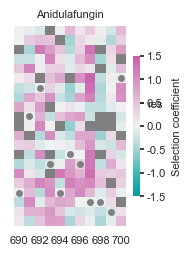

In [17]:
from matplotlib.ticker import MultipleLocator

# Convert conditions to title labels
title_dict = {'none':'Control',
              'dox':'Doxycycline control\n(Paralog repressed)',
              'anidulafungin':'Anidulafungin',
              'caspofungin':'Caspofungin',
              'micafungin':'Micafungin'
             }

# Purge graph space
sns.set(rc = {'figure.figsize':(1.8, 2.6),
              'font.size':8,
              'legend.title_fontsize':8, 'legend.fontsize':8,
              'axes.labelsize':8,'axes.titlesize':8,
              'xtick.labelsize':8, 'ytick.labelsize':8,
             },
       style='whitegrid')
f, ax = plt.subplots()

# Custom color palette
ccmap = sns.color_palette("blend:#009B9E,#42B7B9,#A7D3D4,#F1F1F1,#E4C1D9,#D691C1,#C75DAB", # CARTOColors Tropic
                          as_cmap=True)
ccmap.set_bad('.5') # Color for missing values

# Mask for missing values
mask = pd.isnull(wide_aa)

# Draw heatmap
ax = sns.heatmap(wide_aa, mask=mask, 
                 cmap=ccmap,
                 vmin=-1.5, center=0, vmax=1.5,
                 #xticklabels=len(wtaa)-1,
                 xticklabels=2,
                 yticklabels=False,
                 cbar_kws={'label':'Selection coefficient',
                           'shrink':.7
                          }
                )

ax.set_title(title_dict[compound])
ax.set(xlabel=None, ylabel=None)
ax.tick_params(axis='x', length=3)

cax = ax.figure.axes[-1]
cax.set_yticks([x for x in cax.get_yticks()]+[thresh], labels=[x for x in cax.get_yticks()]+[cax_label])
cax.tick_params(length=3, pad=2)

# Coordinates of WT protein sequence on the heatmap are extracted from the dataframe
# Coordinates should be OK even if the dataframe contains missing values
wtcoord_aa = [(i+0.5, list(aa_sort_order).index(v)+0.5) for i,v in enumerate(wtaa)]

for o in wtcoord_aa:
    ax.plot(o[0],o[1], marker='o', color='.5', markersize=4) # displays WT sequence

# Variants for which we inferred the DMS score
#estimate_coord = [(a+0.75-pos_offset[locus], list(aa_sort_order).index(b)+0.25) for a, b in zip(rescued_filtered.aa_pos, rescued_filtered.alt_aa)]

#for m in estimate_coord:
#    ax.plot(m[0],m[1], marker='*', color='.5', markersize=2)

# Graphs are output in the specified folder
plt.savefig(mgraph_outpath+cset_name+'_aa_heatmap_median_s.svg', format='svg', dpi=300)